In [1]:
## importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
## loading the csv data to a Pandas DataFrame
df = pd.read_csv('../data/heart.csv')

In [3]:
## print the 5 first rows of the dataset
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
## print the 5 last rows of the dataset
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [5]:
## number of rows and columns in the dataset
df.shape

(1025, 14)

In [6]:
## some informations about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
## statistical measurements about the data
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
## checking for missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
## removing the duplicates
df = df.drop_duplicates()
df.shape

(302, 14)

In [10]:
## checking the distribution of the target
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

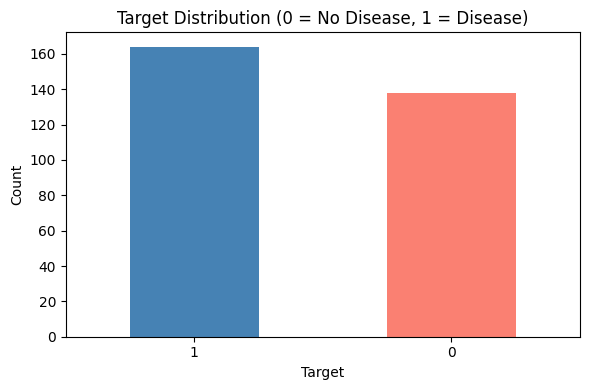

In [11]:
## visualizing the target distribution
plt.figure(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Target Distribution (0 = No Disease, 1 = Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

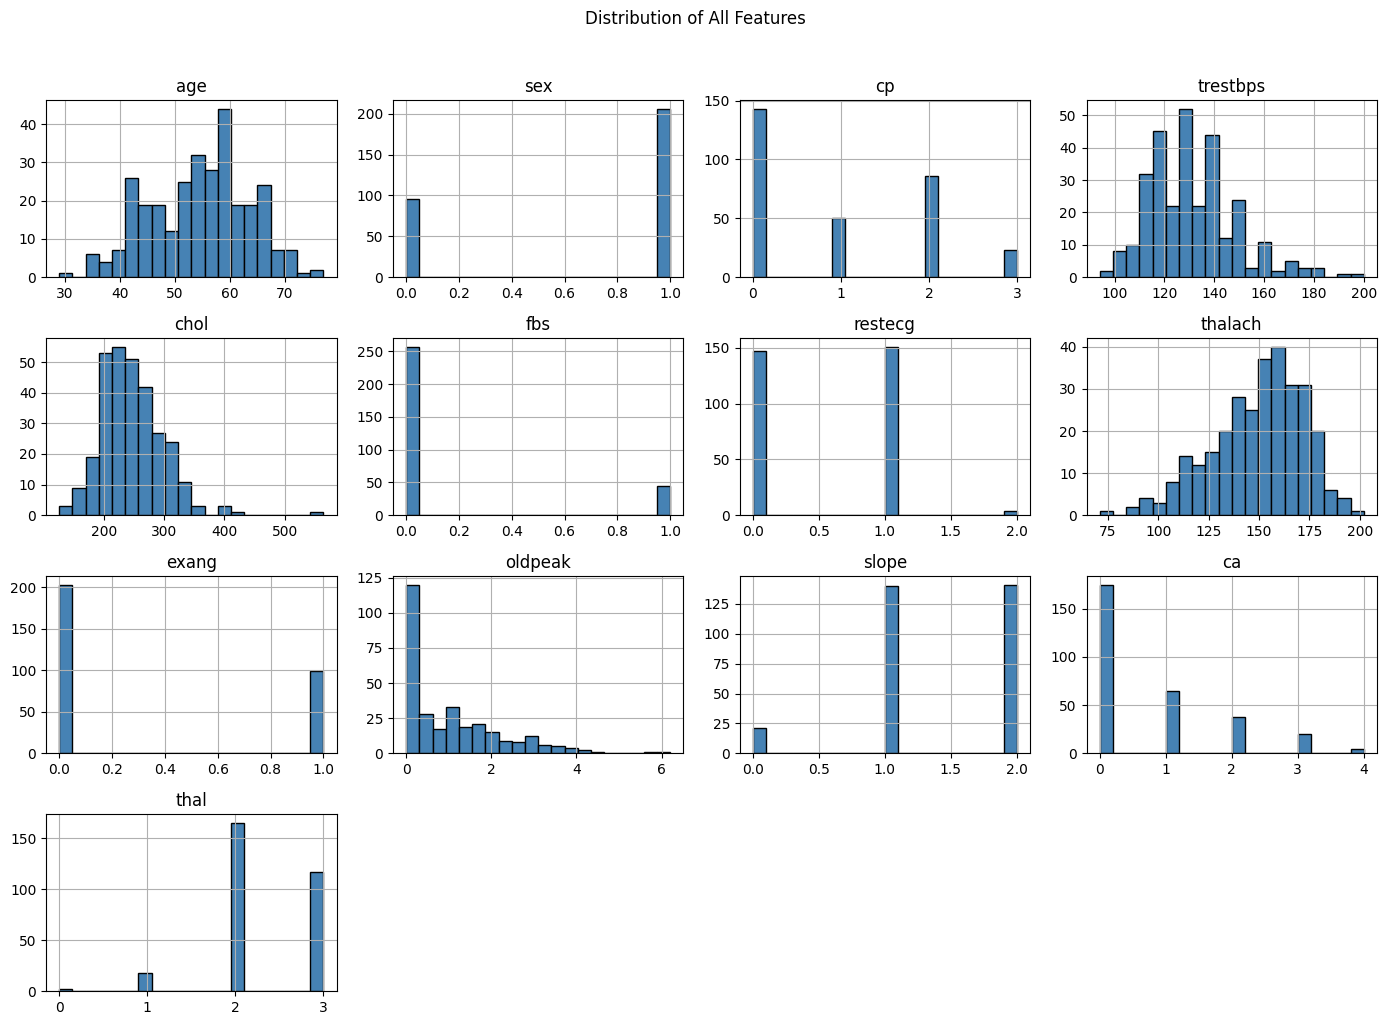

In [25]:
## visualizing the distribution of numerical features
X.hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of All Features', y=1.02)
plt.tight_layout()
plt.show()

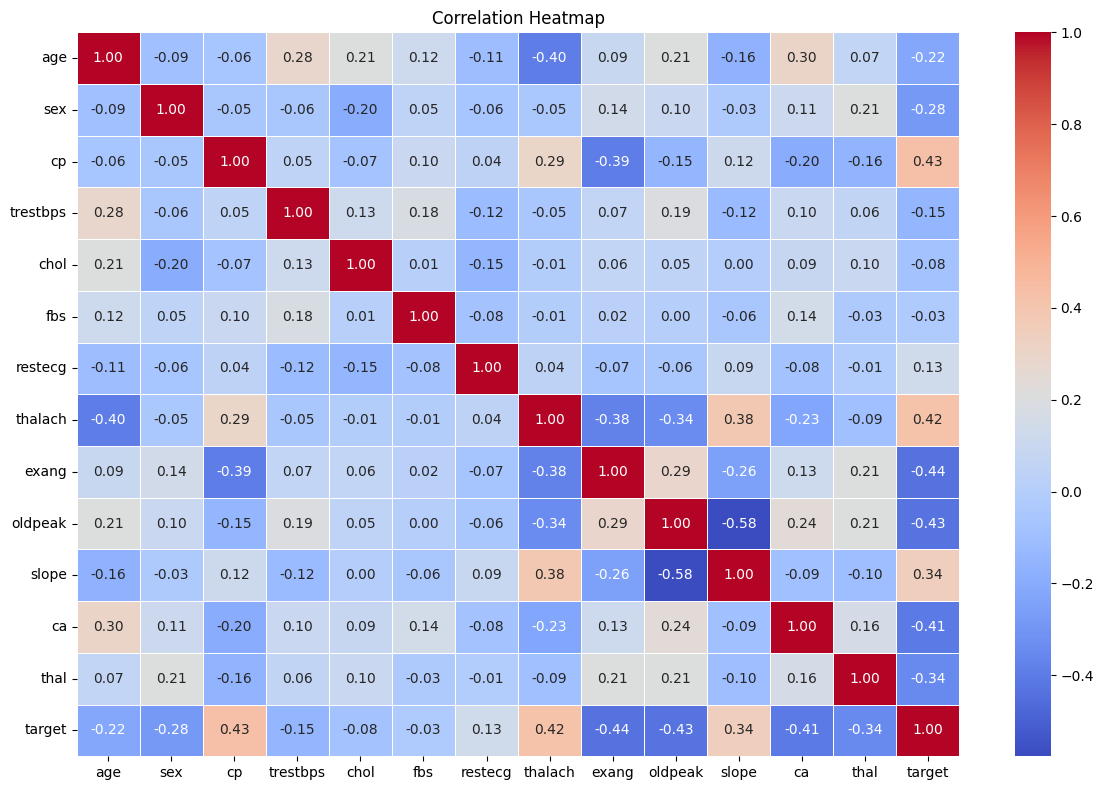

In [13]:
## correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

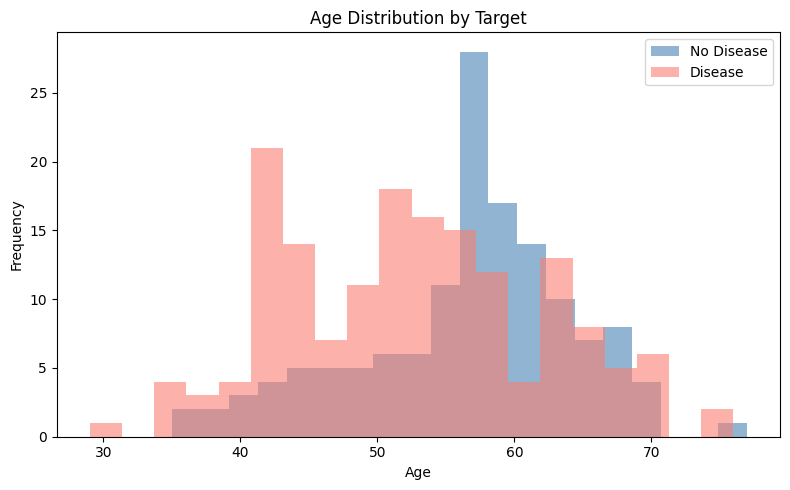

In [14]:
## age distribution by target
plt.figure(figsize=(8, 5))
df[df['target'] == 0]['age'].plot(kind='hist', alpha=0.6, color='steelblue', label='No Disease', bins=20)
df[df['target'] == 1]['age'].plot(kind='hist', alpha=0.6, color='salmon', label='Disease', bins=20)
plt.title('Age Distribution by Target')
plt.xlabel('Age')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
## splitting the features and the target
X = df.drop(columns='target')
Y = df['target']

In [16]:
print(X)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     52    1   0       125   212    0        1      168      0      1.0   
1     53    1   0       140   203    1        0      155      1      3.1   
2     70    1   0       145   174    0        1      125      1      2.6   
3     61    1   0       148   203    0        1      161      0      0.0   
4     62    0   0       138   294    1        1      106      0      1.9   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
723   68    0   2       120   211    0        0      115      0      1.5   
733   44    0   2       108   141    0        1      175      0      0.6   
739   52    1   0       128   255    0        1      161      1      0.0   
843   59    1   3       160   273    0        0      125      0      0.0   
878   54    1   0       120   188    0        1      113      0      1.4   

     slope  ca  thal  
0        2   2     3  
1        0   0     3  
2        0   0    

In [17]:
print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
723    1
733    1
739    0
843    0
878    0
Name: target, Length: 302, dtype: int64


In [18]:
## splitting the data into training data and test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)
print(X.shape, X_train.shape, X_test.shape)

(302, 13) (241, 13) (61, 13)


In [19]:
## scaling the features 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
## model training
# Logistic Regression
model1 = LogisticRegression(max_iter=1000)
# Decision Tree Classifier
model2 = DecisionTreeClassifier(random_state=2)

model1.fit(X_train, Y_train)
model2.fit(X_train, Y_train)

y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)

In [21]:
## accuracy evaluation
print('Logistic Regression Accuracy :', accuracy_score(Y_test, y_pred1))
print('Decision Tree Accuracy       :', accuracy_score(Y_test, y_pred2))


Logistic Regression Accuracy : 0.819672131147541
Decision Tree Accuracy       : 0.7540983606557377


In [26]:
## classification report (precision, recall, f1-score)
print('Logistic Regression :')
print(classification_report(Y_test, y_pred1))

print('Decision Tree :')
print(classification_report(Y_test, y_pred2))

Logistic Regression :
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.85      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

Decision Tree :
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



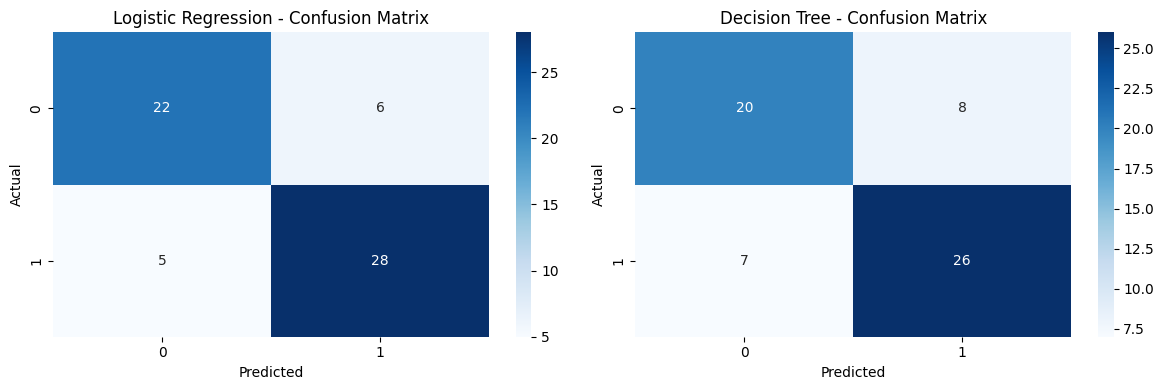

In [23]:
## confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(Y_test, y_pred1), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(Y_test, y_pred2), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Decision Tree - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [28]:
## building a predictive system

# user enters the data
print('Please enter the following values:')
age      = float(input('Age: '))
sex      = float(input('Sex (1=Male, 0=Female): '))
cp       = float(input('Chest Pain Type (0-3): '))
trestbps = float(input('Resting Blood Pressure: '))
chol     = float(input('Cholesterol: '))
fbs      = float(input('Fasting Blood Sugar > 120mg (1=True, 0=False): '))
restecg  = float(input('Resting ECG (0-2): '))
thalach  = float(input('Max Heart Rate Achieved: '))
exang    = float(input('Exercise Induced Angina (1=Yes, 0=No): '))
oldpeak  = float(input('ST Depression (oldpeak): '))
slope    = float(input('Slope of ST Segment (0-2): '))
ca       = float(input('Number of Major Vessels (0-4): '))
thal     = float(input('Thal (0-3): '))

input_data = (age, sex, cp, trestbps, chol, fbs, restecg,
              thalach, exang, oldpeak, slope, ca, thal)

# change the input data to a DataFrame to avoid warnings
input_df = pd.DataFrame([input_data], columns=X.columns)

# scale the input data using the same scaler used in training
input_data_scaled = scaler.transform(input_df)

prediction = model1.predict(input_data_scaled)

print(prediction)
if (prediction[0] == 0):
    print('\nThe Person does not have a Heart Disease')
else:
    print('\nThe Person has a Heart Disease')

Please enter the following values:


Age:  62
Sex (1=Male, 0=Female):  0
Chest Pain Type (0-3):  0
Resting Blood Pressure:  140
Cholesterol:  268
Fasting Blood Sugar > 120mg (1=True, 0=False):  0
Resting ECG (0-2):  0
Max Heart Rate Achieved:  160
Exercise Induced Angina (1=Yes, 0=No):  0
ST Depression (oldpeak):  3
Slope of ST Segment (0-2):  0
Number of Major Vessels (0-4):  2
Thal (0-3):  2


The Person does not have a Heart Disease
